# NetworkX: Graph Theory

## 1. Basics
A graph models objects and the connections between them (like people and friendships, or cities and roads). This makes it useful for studying how things are linked, finding routes, and spotting important nodes or groups in a network.

### 1.1. Definition
A graph is written as $G=(V,E)$, where $V$ is the set of vertices/nodes and $E$ is the set of edges/links. In Python, NetworkX is a common library for creating and analyzing graphs. You can create graph using an edge list, a neighbor list or an adjacency matrix.

|Format|[From Python object]|[From file]|
|:-|:-|:-|
|Edge list|`nx.from_edgelist()`|`nx.read_edgelist()`|
|Neighbor list|`nx.from_dict_of_lists()`|`nx.read_adjlist()`|
|Adjacency matrix|`nx.from_numpy_matrix()`||

[From Python object]: https://networkx.org/documentation/stable/reference/convert.html
[From file]: https://networkx.org/documentation/stable/reference/readwrite/index.html

In [1]:
import sys; sys.path.append('..')
from mlkit import np, pd, nx, plt, sns

In [73]:
edges = [(1,2), (2,3), (3,4), (4,5)]
ge = nx.from_edgelist(edges)

In [74]:
neighbors = {
    'A': ['B', 'D'],
    'B': ['A', 'C'],
    'C': ['B'],
    'D': ['A']
}

gn = nx.from_dict_of_lists(neighbors)

In [2]:
adj_matrix = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
])

gm = nx.from_numpy_array(adj_matrix)

:::{admonition} Pitfall
:class: danger

NetworkX allows you to draw graphs, but layouts can trick your eyes: nodes might look close just because the drawing algorithm placed them that way. Always support a picture with numbers (degree, components, distances), not just the drawing.

:::

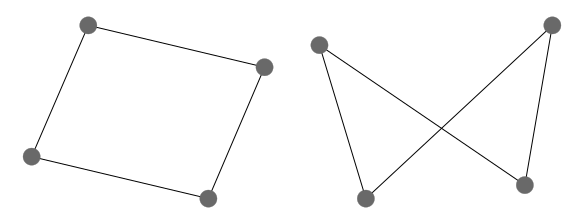

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
nx.draw(gm, ax=ax[0], pos=nx.spring_layout(gm, seed=0), node_color='dimgrey')
nx.draw(gm, ax=ax[1], pos=nx.spring_layout(gm, seed=10), node_color='dimgrey')
plt.show()

### 1.2. Key vocabulary
- Adjacent: Two nodes are adjacent if there is an edge between them. They are also called neighbors.
- Degree: The degree of a node is how many edges touch it.
- Path: A path is a sequence of nodes connected by edges, like A-B-C.
- Cycle: A cycle is a path that starts and ends at the same node, like A-B-C-A.
- Connected graph: An undirected graph is connected if every node can reach every other node through some path. If not, it has connected components (separate *islands*).

### 1.3. Types of graphs
- Directed graph: edges have direction, for example: social networks follows.
- Weighted graph: edges have weights, for example: distances between cities.
- Bipartite graph: nodes can be divided into two sets, and edges only connect nodes from different sets, for example: users and the movies they rate.
- Tree: a special graph with no cycles, for example: family trees.

In [77]:
dg = nx.DiGraph()
dg.add_edge('A', 'B')

In [78]:
wg = nx.Graph()
wg.add_edge('A', 'B', weight=5)
wg.add_edge('B', 'C', weight=2)

In [79]:
students = ['S1', 'S2']
classes = ['Math', 'History']

bg = nx.Graph()
bg.add_nodes_from(students, bipartite=0)
bg.add_nodes_from(classes, bipartite=1)
bg.add_edges_from([('S1', 'Math'), ('S2', 'Math'), ('S2', 'History')])

### 1.4. Statistics
- Size: $|V|$ nodes, $|E|$ edges
- Density: how full the graph is (0 = sparse, 1 = complete)
- Degree summary: min/avg/max degree, top-degree nodes
- Connectivity: number of components, size of largest component

In [80]:
adj_matrix = np.array([
    [0, 1, 1, 1],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0],
])

g = nx.from_numpy_array(adj_matrix)

In [81]:
# g.number_of_edges()
# g.number_of_nodes()
# nx.density(g)
nx.is_connected(g)

True

In [82]:
degrees = dict(g.degree())
max_degree = max(degrees.values())
avg_degree = sum(degrees.values()) / len(degrees)

In [83]:
# handshake lemma
sum(degrees.values()) == 2 * g.number_of_edges()

True

## 2. Graph algorithms

### 2.1. Graph traversal
Traversal is a general strategy for exploring a graph: starting from a chosen node, you systematically visit reachable nodes (usually once each). Traversal isn't the answer by itself, it's a building block used inside many graph tasks like reachability, finding connected components, detecting cycles, or building shortest paths.

#### Depth-First Search
The idea of [Depth-First Search] (DFS) is to explore as deep as possible along each branch before backtracking. You can implement it using recursion or a [stack]. DFS is good for tasks like cycle detection and topological sorting. Here is how it works conceptually:
- Start at a chosen node, mark it as visited.
- Visit and unvisited neighbor.
- Keep going deeper until you hit a dead end.
- Backtrack to the last node with an unvisited neighbor and continue.

[Depth-First Search]: https://en.wikipedia.org/wiki/Depth-first_search
[stack]: https://en.wikipedia.org/wiki/Stack_(abstract_data_type)

#### Bereadth-First Search
The idea of [Breadth-First Search] (BFS) is to explore all neighbors at the present depth before moving on to nodes at the next depth level. You can implement it using a [queue]. BFS is great for finding the shortest path in unweighted graphs and for level-order traversal. Here is how it works conceptually:
- Start at a chosen node, mark it as visited, and enqueue it.
- Dequeue a node, visit all its unvisited neighbors, mark them as visited, and enqueue them.
- Repeat until the queue is empty.

[Breadth-First Search]: https://en.wikipedia.org/wiki/Breadth-first_search
[queue]: https://en.wikipedia.org/wiki/Queue_(abstract_data_type)

### 2.2. Shortest path
The [shortest path problem] asks how to find a route between two nodes in a graph that has the minimum total cost. The *cost* might be the number of edges (in an unweighted graph) or the sum of edge weights like distance, time or money (in a weighted graph). Shortest path problems are everywhere:
- GPS navigation systems use shortest path algorithms to find the quickest route between locations.
- Internet routing protocols determine the best path for data packets across networks.
- Urban planning utilizes shortest path calculations to optimize public transportation routes.

Depending on the graph and the rules, you might want (1) the shortest path from one source to one target, (2) from one source to all vertices, or (3) between every pair of vertices. Here are some common algorithms:
- [BFS]: solves the single-source shortest path problem for unweighted graphs. It use a brute force design approach, where the core idea is a level-order traversal.
- [Dijkstra]: also solves the single-source shortest path problem but for weighted graphs. It uses a greedy design approach based on the core idea of *priority relaxation*, always expanding the node with the smallest confirmed distance.
- [Bellman-Ford]: extends Dijkstra to handle graphs with negative edge weights. It employs a dynamic programming design approach, using *iterative relaxation* of all edges to ensure shortest paths are found, while also detecting negative cycles.
- [A\* Search]: targets the single-pair shortest path problem, often used in navigation. It uses a heuristic search design approach, combining actual cost from the start and an estimated cost to the target to prioritize paths.
- [Floyd-Warshall]: addresses the all-pairs shortest path problem. It uses a dynamic programming design approach based on the concept of *intermediate pivots*, iteratively checking if paths can be improved by passing through other nodes.

[shortest path problem]: https://en.wikipedia.org/wiki/Shortest_path_problem
[BFS]: https://en.wikipedia.org/wiki/Breadth-first_search
[Dijkstra]: https://en.wikipedia.org/wiki/Dijkstra%27s_algorithm
[A\* Search]: https://en.wikipedia.org/wiki/A*_search_algorithm
[Bellman-Ford]: https://en.wikipedia.org/wiki/Bellman%E2%80%93Ford_algorithm
[Floyd-Warshall]: https://en.wikipedia.org/wiki/Floyd%E2%80%93Warshall_algorithm

### 2.3. Euler path
The [Euler path] problem asks whether you can traverse a graph by following edges without repeating any edge. An Euler path uses every edge exactly once and may start and end at different vertices, while an Euler cycle (or circuit) uses every edge exactly once and returns to the starting vertex. These problems show up in real life:

- Route inspection (e.g., street sweeping, snow plowing, mail delivery) models cover every road segment once to reduce repeated travel.
- Designing efficient test routes in networks (cables, pipelines, power lines) can be framed as traversing each connection with minimal repetition.
- Puzzle and game design (like drawing figures in one stroke) often relies on Euler path/cycle rules.

Depending on the graph type, you might ask (1) whether an Euler path/cycle exists, (2) how to construct one, or (3) how to modify the graph to make one possible (e.g., adding the fewest edges, which leads toward the Chinese Postman problem). Here are some common approaches and algorithms:

- Degree condition (existence test): determines if an Euler path/cycle exists by checking vertex degrees (and connectivity). It uses a proof-based design approach: in an undirected connected graph, an Euler cycle exists iff all vertices have even degree; an Euler path exists iff exactly two vertices have odd degree (or none, for a cycle).
- Hierholzer's algorithm: constructs an Euler cycle (and can be adapted for an Euler path) in linear time. It uses a constructive design approach based on building and merging cycles: walk unused edges to form a cycle, then splice in additional cycles from vertices with remaining unused edges.
- Fleury's algorithm: also constructs an Euler path/cycle by repeatedly choosing a safe next edge (avoid breaking connectivity too early). It uses a greedy design approach guided by the idea of avoiding bridges when possible, though it is typically less efficient than Hierholzer.

[Euler path]: https://en.wikipedia.org/wiki/Eulerian_path

::::{admonition} Case
:class: tip

The idea of Euler path originated from classic puzzles like the Seven Bridges of Königsberg, where the question is whether one can cross each bridge exactly once

:::{image} ../image/chap_02/seven_bridges.png
:height: 400px
:align: center
:::

::::

### 2.4. Hamilton path

The Hamilton path/cycle problem asks whether you can visit every vertex in a graph exactly once. A Hamilton path visits each vertex once and may start and end at different vertices, while a Hamilton cycle (or circuit) visits each vertex once and returns to the starting vertex. Unlike Euler paths (which focus on edges), Hamilton problems focus on vertices and are often much harder to solve in general. They appear in many real-world tasks:

- Planning a route that visits a set of locations exactly once (deliveries, inspections, campus tours) can be modeled as a Hamilton path variant.
- Circuit design and robotics use visit each required checkpoint once planning to reduce repetition and cost.
- Many puzzles and games (e.g., finding a tour that visits every node once) are naturally Hamiltonian.

Depending on the goal, you might want (1) to determine whether a Hamilton path/cycle exists, (2) to construct one if it exists, or (3) to find the best such tour under costs, which leads to the [Traveling Salesman Problem] (TSP). Here are some common approaches and algorithms:

- Backtracking/brute-force search: tries candidate vertex orders and prunes when the partial route cannot be extended. It uses a brute force design approach with pruning to reduce the search space, but can still be exponential in the worst case.
- Dynamic programming (Held–Karp style): solves Hamiltonian path/cycle with subset-based DP by tracking the best way to reach a vertex after visiting a set of vertices. It uses a dynamic programming design approach based on subset states, improving over naive brute force but remaining exponential.
- Dirac/Ore-type sufficient conditions: provides quick tests that guarantee a Hamilton cycle under strong degree conditions (though failing the test does not mean no Hamilton cycle exists). It uses a theory-driven design approach based on vertex degree properties.
- [Ant Colony Optimization]: searches for a Hamilton path/cycle by simulating many “ants” that build routes step by step using probabilistic choices guided by pheromone trails and heuristic desirability (e.g., prefer shorter edges). It uses a metaheuristic design approach based on reinforcement through pheromone updates, gradually biasing the search toward better tours.
- [Genetic Algorithm]: treats each candidate tour as a chromosome and evolves a population of tours using selection, crossover, and mutation. It uses an evolutionary metaheuristic design approach, repeatedly combining and perturbing routes to explore the solution space and keep higher-quality tours more likely to survive.


[Traveling Salesman Problem]: https://simple.wikipedia.org/wiki/Travelling_salesman_problem
[Ant Colony Optimization]: https://en.wikipedia.org/wiki/Ant_colony_optimization_algorithms
[Genetic Algorithm]: https://en.wikipedia.org/wiki/Genetic_algorithm

### 2.5. Graph coloring

The graph coloring problem asks how to assign colors to vertices of a graph so that no two adjacent vertices share the same color. The goal is often to use as few colors as possible; this minimum number is called the chromatic number. Graph coloring appears in many practical situations:

- Exam timetabling: courses that share students cannot be scheduled at the same time, so each time slot acts like a “color.”
- Register allocation in compilers: variables that are “alive” at the same time cannot share a CPU register, so registers act like colors.
- Frequency assignment in wireless networks: nearby transmitters must use different frequencies to avoid interference.

Depending on the setting, you might want (1) to decide whether k colors are enough (k-colorability), (2) to find a coloring using the fewest colors, or (3) to color edges or regions (map coloring) instead of vertices. Here are some common approaches and algorithms:

- Greedy coloring: colors vertices one by one using the smallest available color. It uses a greedy design approach, and the result depends heavily on the vertex ordering.
- DSATUR: chooses the next vertex with the highest saturation degree (the number of different colors used by its neighbors). It uses a greedy design approach with a stronger selection rule to reduce color usage in practice.
- Backtracking / branch-and-bound: searches for an optimal coloring while pruning impossible partial assignments. It uses a brute force design approach with pruning, often effective on small or structured graphs.
- Approximation and heuristic methods: for large graphs, methods like local search, tabu search, or evolutionary strategies aim for near-minimal colorings. It uses a heuristic or approximation design approach to trade optimality guarantees for speed and scalability.

## 3. Network analysis

### 3.1. PageRank
[PageRank] was originally invented by Google in 1998 and had became an extraordinary success as a search engines. It makes clever use of the eigenvalues to rank hundreds of millions websites, which delivers the most relevant result for the search queries. In NetworkX, the algorithm is implemented via the function [`pagerank()`].

[PageRank]: https://en.wikipedia.org/wiki/PageRank
[`pagerank()`]: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html

In the next sections, we explore PageRank on a small system containing $N=6$ websites. We use a directed graph to encode this system, where each node is a website and each edge is a link from a website to another. Our target is to find a *scoring vector* $\mathbf{r}\in\mathbb{R}^N$, in which the score of any website, $r_n>0$, should be higher if:
- The website index $n$ has more backlinks
- Those backlinks are from websites with high scores

In [5]:
import sys; sys.path.append('..')
from mlkit import np, pd, nx, plt, sns

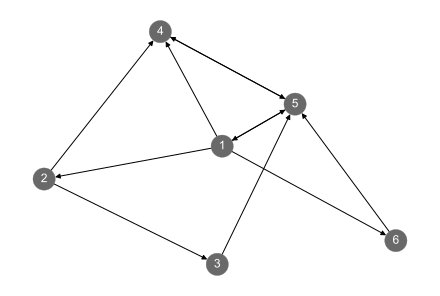

In [6]:
web_graph = nx.DiGraph()
web_graph.add_nodes_from([1, 2, 3, 4, 5, 6])
web_graph.add_edges_from([
    (1, 2), (1, 4), (1, 5), (1, 6),
    (2, 3), (2, 4),
    (3, 5),
    (4, 5),
    (5, 1), (5, 4),
    (6, 5)
])

fig, ax = plt.subplots(figsize=(6, 4))
pos = pos=nx.spring_layout(web_graph, seed=19)
nx.draw(web_graph, node_color='dimgrey', font_color='w', with_labels=True, node_size=500, pos=pos, ax=ax)

#### Eigenvalue centrality

:::{admonition} Case
:class: tip

The website P4 has three backlinks from pages P1, P2 and P5. We construct an equation represents how scores are transferred through the backlinks:

$$r_4=r_1+r_2+r_5$$

However, the pages P1, P2 and P5 transfer their points to other pages as well. In this case, P1 has $\ell_1=4$ forward links, P2 and P5 have $\ell_2=\ell_5=2$ forward links. The *transition equation* is written as:

$$r_4=\frac{r_1}{\ell_1}+\frac{r_2}{\ell_2}+\frac{r_5}{\ell_5}$$

:::

In general, all pages keep giving and recieving scores continuously. Instead of observing each page standalone, we write the whole *transition equation* using matrix notation:

$$\mathbf{Ar}=\mathbf{r}$$

Here, $\mathbf{A}$ is the *transition matrix*. Each column of $\mathbf{A}$ is a [probability vector] showing how a page distributes its score. This makes $\mathbf{A}$ a [stochastic matrix], which has $\lambda=1$ the dominant eigenvalue (under [Perron-Frobenius theorem]). By injecting $\lambda$ to the transition equation, $\mathbf{r}$ becomes the dominant eigenvector of $\mathbf{A}$.

[probability vector]: https://en.wikipedia.org/wiki/Probability_vector
[stochastic matrix]: https://en.wikipedia.org/wiki/Stochastic_matrix
[Perron-Frobenius theorem]: https://en.wikipedia.org/wiki/Perron%E2%80%93Frobenius_theorem

In [10]:
def get_transition_matrix(graph):
    adj_matrix = nx.adjacency_matrix(graph).todense().T
    out_degree = adj_matrix.sum(axis=0)
    share_weight = np.divide(1, out_degree, where=out_degree!=0)
    transition_matrix = np.multiply(adj_matrix, share_weight)
    return transition_matrix

transition_matrix = get_transition_matrix(web_graph)
print(transition_matrix)

[[0.   0.   0.   0.   0.5  0.  ]
 [0.25 0.   0.   0.   0.   0.  ]
 [0.   0.5  0.   0.   0.   0.  ]
 [0.25 0.5  0.   0.   0.5  0.  ]
 [0.25 0.   1.   1.   0.   1.  ]
 [0.25 0.   0.   0.   0.   0.  ]]


In [11]:
def get_dominant_eigenvector(transition_matrix):
    eigenvalues, eigenvectors = np.linalg.eig(transition_matrix)
    dominant_idx = np.argmax(np.real(eigenvalues))
    dominant_eigenvector = np.real(eigenvectors[:, dominant_idx])
    dominant_eigenvector = dominant_eigenvector / np.sum(dominant_eigenvector)
    return dominant_eigenvector

pagerank_vector = get_dominant_eigenvector(transition_matrix)
pagerank_vector

array([0.2  , 0.05 , 0.025, 0.275, 0.4  , 0.05 ])

:::{note}
There are other types of [centrality] beside eigenvalue centrality:
- Degree centrality is the degree of the node.
- Closeness centrality is the average length of the shortest path between the node and all other nodes.
- Betweeness centrality is the number of time a node acts as a bridge along the shortest path between two other nodes. 
:::

[centrality]: https://en.wikipedia.org/wiki/Centrality

#### Damping factor
With the introduction of the *damping factor* $\alpha$, PageRank assumes that internet users randomly teleport to pages other than forward links at the probability of $1-\alpha$. The dampen transition equation is given by:

$$
\begin{aligned}
\mathbf{r}
&= \alpha \mathbf{A}\mathbf{r} + (1 - \alpha)\mathbf{p} \\
&= \left( \alpha \mathbf{A} + (1 - \alpha)\mathbf{p1}^\top \right) \mathbf{r} \\
&= \mathbf{A}'\mathbf{r}
\end{aligned}
$$

Where:
- $\mathbf{p}=\mathbf{1}/n$ is the teleport vector
- $\mathbf{A}'=\alpha\mathbf{A}+(1-\alpha)\mathbf{p1}^\top$ is the dampen transition matrix

As $\mathbf{A}'$ is still a stochastic matrix, processing damping factor only requires updating the transition matrix without changing other calculations.

In [12]:
def get_transition_matrix(graph, alpha=0.85):
    adj_matrix = nx.adjacency_matrix(graph).todense().T
    out_degree = adj_matrix.sum(axis=0)
    share_weight = np.divide(1, out_degree, where=out_degree!=0)
    transition_matrix = np.multiply(adj_matrix, share_weight)

    n = transition_matrix.shape[0]
    transition_matrix *= alpha
    transition_matrix += (1 - alpha) * np.ones((n, n)) / n
    return transition_matrix

dampen_transition_matrix = get_transition_matrix(web_graph)
print(dampen_transition_matrix)

[[0.025  0.025  0.025  0.025  0.45   0.025 ]
 [0.2375 0.025  0.025  0.025  0.025  0.025 ]
 [0.025  0.45   0.025  0.025  0.025  0.025 ]
 [0.2375 0.45   0.025  0.025  0.45   0.025 ]
 [0.2375 0.025  0.875  0.875  0.025  0.875 ]
 [0.2375 0.025  0.025  0.025  0.025  0.025 ]]


#### Power iteration
In real life, there are billions of websites it's not possible to calculate the dominant eigenvector algebraically. Accordingly, a method for estimating the dominant eigenvector called the [power iteration] is used. This method initializes $\mathbf{r_0}$ arbitrary, then keep multiplying the matrix $\mathbf{A}$ to get $\mathbf{r}$:

$$\mathbf{r}=\lim_{p\rightarrow\infty}\mathbf{A}^p\,\mathbf{r_0}$$

Many implementations have pointed out that the convergence happens very fast, taking only about 100 iterations in case of millions of pages

[power iteration]: https://en.wikipedia.org/wiki/Power_iteration

In [8]:
def power_iteration(transition_matrix, max_iter=100, tol=1e-6):
    n = transition_matrix.shape[0]
    init_vector = np.ones(n) / n
    pagerank_vector = init_vector
    for _ in range(max_iter):
        next_vector = transition_matrix @ pagerank_vector
        error_vector = next_vector - pagerank_vector
        if np.linalg.norm(error_vector, 1) < tol:
            break
        pagerank_vector = next_vector
    return pagerank_vector

In [13]:
power_iteration(transition_matrix)

array([0.2  , 0.05 , 0.025, 0.275, 0.4  , 0.05 ])

In [14]:
# try with less iterations
power_iteration(transition_matrix, max_iter=10)

array([0.2025, 0.0492, 0.0256, 0.2772, 0.3964, 0.0492])

In [15]:
# try with damping factor
pagerank_vector = power_iteration(dampen_transition_matrix)
pagerank_vector

array([0.1861, 0.0646, 0.0524, 0.2531, 0.3792, 0.0646])

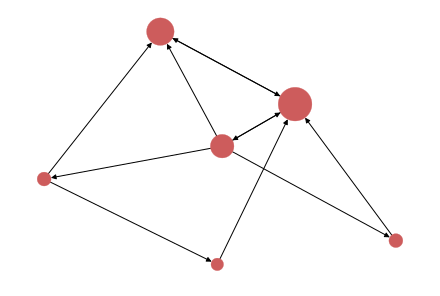

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
pos = pos=nx.spring_layout(web_graph, seed=19)
nx.draw(
    web_graph,
    node_color='indianred',
    node_size=pagerank_vector * 500 * web_graph.number_of_nodes(),
    pos=pos,
    ax=ax,
)

### 3.2. Graph clustering
At its core, graph clustering is the process of grouping objects based on their relationships rather than just their individual characteristics.While traditional clustering looks at *what an object is* (e.g., color, size, or age), graph clustering looks at *who an object knows*. Graph clustering is behind how we understand complex systems:
- Social Networks: Discovering "circles of friends" or interest-based communities for targeted advertising.
- Biology: Identifying groups of proteins that work together to perform a specific cellular function or cause a disease.
- Cybersecurity: Detecting "fraud rings" where accounts interact exclusively with each other to launder money or spread misinformation.
- Recommendation Systems: Grouping similar products based on co-purchase history to suggest "frequently bought together" items.

A successful graph cluster always aims for high external density (lots of connections inside the group), low internal density (very few connections to the outside) and high modularity (better than random versions of the same network).

#### Algorithms
It’s best to look at the three most influential ways we "slice" a graph. Each uses a different mathematical superpower to find groups.
- Louvain Algorithm (The Greedy Optimizer): A bottom-up approach that maximizes Modularity. It moves nodes into neighboring groups to increase internal density, then collapses those groups into super-nodes to find a multi-level hierarchy. Best for: Massive networks where you don't know the number of groups.
- Girvan-Newman (The Bridge Burner): A top-down divisive method that targets Edge Betweenness. It identifies and cuts the bridges (bottlenecks) that connect different communities until the graph fractures into separate clusters. Best for: Deeply analyzing the structure of smaller networks
- Spectral Clustering (The Matrix Solver): A mathematical approach using the Laplacian matrix. It uses eigenvectors to project the graph into a coordinate system where nodes that belong together are physically close, then applies standard clustering. Best for: Finding a specific, pre-defined number of clusters.

## Resources
- googleapis.com - [Method for node ranking in a linked database](https://patentimages.storage.googleapis.com/37/a9/18/d7c46ea42c4b05/US6285999.pdf)
- googleapis.com - [Producing a ranking for pages using distances in a web-link graph](https://patentimages.storage.googleapis.com/b8/dc/3e/3b5b32f8acd264/US9165040.pdf)
- trenton3983.github.io - [Introduction to Network Analysis in Python](https://trenton3983.github.io/files/projects/2020-05-21_intro_to_network_analysis_in_python/2020-05-21_intro_to_network_analysis_in_python.html)
- reliantsproject.com - [Seven Bridges of Konigsberg and the Origin of Network Graphs](https://www.reliantsproject.com/2020/06/07/concept-1-seven-bridges-of-konigsberg-and-the-origin-of-network-graphs/)